In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [16]:
df=pd.read_csv("svr_dataset.csv")
df

,age,income,loan_amount,credit_score,city,employment_type,target
0,56,25903.305196,286348.192562,789.476075,Chennai,Salaried,158793.631698
1,69,53051.954538,180018.190719,596.334039,Chennai,Salaried,115596.093965
2,46,38654.738821,211234.236288,611.531000,Chennai,Salaried,127231.057638
3,32,28666.194356,246629.541594,710.171152,Chennai,Unemployed,145102.187078
4,60,40301.406736,129081.713353,622.900855,Hyderabad,Unemployed,110623.128404
...,...,...,...,...,...,...,...
995,60,NaN,272663.033166,502.604714,Chennai,Salaried,155285.942941
996,64,36687.617333,133069.710014,730.751324,Bangalore,Self-Employed,65076.404995
997,62,43438.125495,234645.931152,747.044458,Hyderabad,Unemployed,126006.462108
998,35,60835.720367,169706.958962,628.847359,Bangalore,Unemployed,118101.789665


age                Axes(0.125,0.653529;0.352273x0.226471)
income          Axes(0.547727,0.653529;0.352273x0.226471)
loan_amount        Axes(0.125,0.381765;0.352273x0.226471)
credit_score    Axes(0.547727,0.381765;0.352273x0.226471)
target                 Axes(0.125,0.11;0.352273x0.226471)
dtype: object

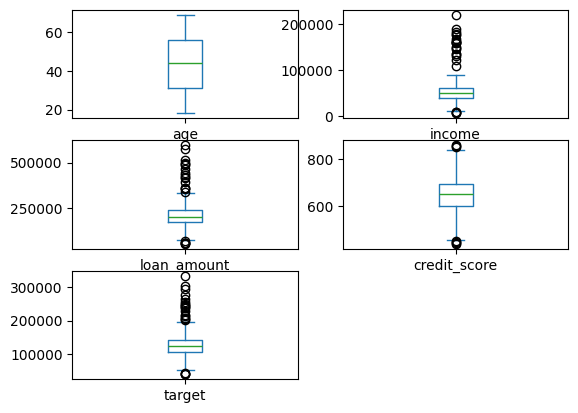

In [17]:
df.plot(kind="box",layout=(3,2),subplots=True)

age                Axes(0.125,0.653529;0.352273x0.226471)
income          Axes(0.547727,0.653529;0.352273x0.226471)
loan_amount        Axes(0.125,0.381765;0.352273x0.226471)
credit_score    Axes(0.547727,0.381765;0.352273x0.226471)
target                 Axes(0.125,0.11;0.352273x0.226471)
dtype: object

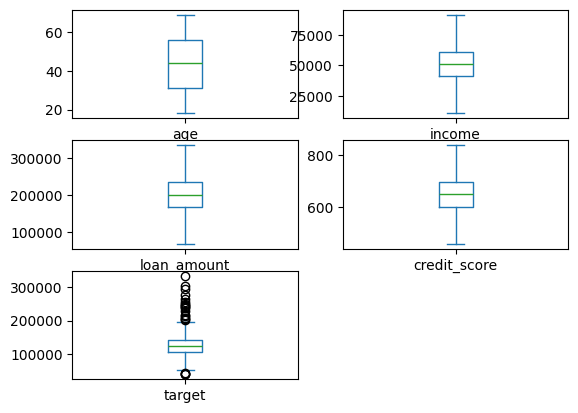

In [18]:
#iqr 
def iqr(col):
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    iqr=q3-q1
    lower_bound=q1-1.5*iqr
    upper_bound=q3+1.5*iqr
    df[col]=df[col].clip(lower_bound,upper_bound)
iqr("income")
iqr("loan_amount")
iqr("credit_score")
df.plot(kind="box",layout=(3,2),subplots=True)

In [19]:
df.isnull().sum()

age                 0
income             30
loan_amount        30
credit_score       29
city                0
employment_type     0
target              0
dtype: int64

<Axes: xlabel='income', ylabel='Count'>

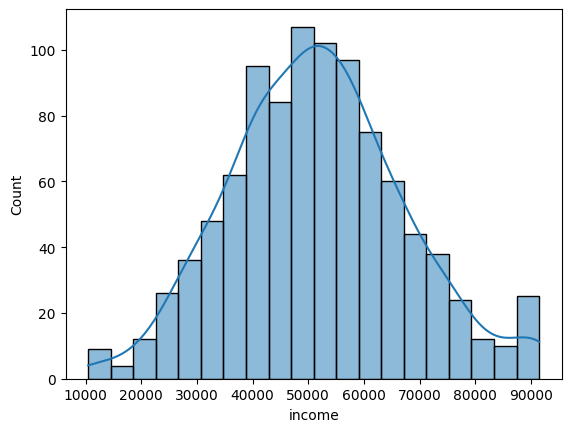

In [20]:
sns.histplot(df["income"],bins=20,kde=True)

<Axes: xlabel='loan_amount', ylabel='Count'>

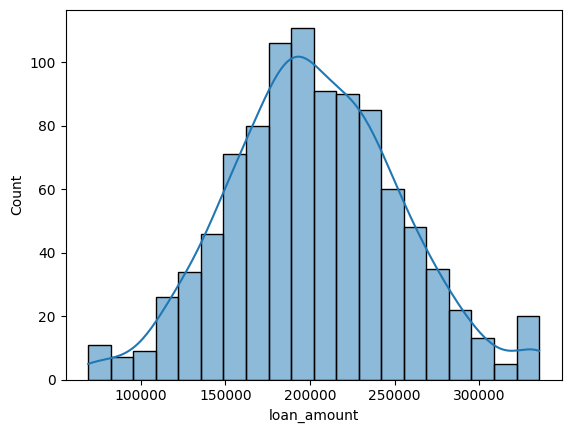

In [21]:
sns.histplot(df["loan_amount"],bins=20,kde=True)

<Axes: xlabel='credit_score', ylabel='Count'>

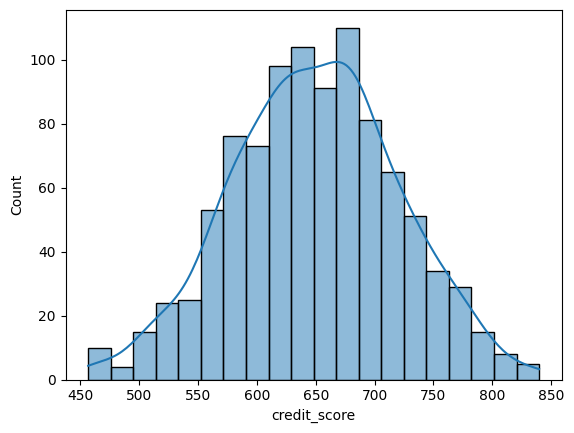

In [22]:
sns.histplot(df["credit_score"],bins=20,kde=True)

In [23]:
df["income"].fillna(df["income"].median(),inplace=True)
df["loan_amount"].fillna(df["loan_amount"].median(),inplace=True)
df["credit_score"].fillna(df["credit_score"].median(),inplace=True)
df.isnull().sum()

C:\Users\91998\AppData\Local\Temp\ipykernel_7764\4211177678.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["income"].fillna(df["income"].median(),inplace=True)
C:\Users\91998\AppData\Local\Temp\ipykernel_7764\4211177678.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

Fo

age                0
income             0
loan_amount        0
credit_score       0
city               0
employment_type    0
target             0
dtype: int64

In [24]:
df.dtypes

age                  int64
income             float64
loan_amount        float64
credit_score       float64
city                object
employment_type     object
target             float64
dtype: object

In [25]:

#encoding using one hot encoding not using dummies
from sklearn.preprocessing import OneHotEncoder
encoder=OneHotEncoder(sparse_output=False)
encoded_data=encoder.fit_transform(df[["city"]])
encoded_df=pd.DataFrame(encoded_data,columns=encoder.get_feature_names_out(["city"])).astype(int)
df=pd.concat([df.drop("city",axis=1),encoded_df],axis=1)
encoder=OneHotEncoder(sparse_output=False)
encoded_data=encoder.fit_transform(df[["employment_type"]])
encoded_df=pd.DataFrame(encoded_data,columns=encoder.get_feature_names_out(["employment_type"])).astype(int)
df=pd.concat([df.drop("employment_type",axis=1),encoded_df],axis=1)
df

,age,income,loan_amount,credit_score,target,city_Bangalore,city_Chennai,city_Hyderabad,city_Mumbai,employment_type_Salaried,employment_type_Self-Employed,employment_type_Unemployed
0,56,25903.305196,286348.192562,789.476075,158793.631698,0,1,0,0,1,0,0
1,69,53051.954538,180018.190719,596.334039,115596.093965,0,1,0,0,1,0,0
2,46,38654.738821,211234.236288,611.531000,127231.057638,0,1,0,0,1,0,0
3,32,28666.194356,246629.541594,710.171152,145102.187078,0,1,0,0,0,0,1
4,60,40301.406736,129081.713353,622.900855,110623.128404,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
995,60,51119.925190,272663.033166,502.604714,155285.942941,0,1,0,0,1,0,0
996,64,36687.617333,133069.710014,730.751324,65076.404995,1,0,0,0,0,1,0
997,62,43438.125495,234645.931152,747.044458,126006.462108,0,0,1,0,0,0,1
998,35,60835.720367,169706.958962,628.847359,118101.789665,1,0,0,0,0,0,1


In [26]:
x=df.drop("target",axis=1)
y=df["target"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)   
#scaling the values
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)
from sklearn.svm import SVR

In [27]:
from sklearn.svm import SVR
model=SVR(kernel="rbf")
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
from sklearn.metrics import mean_squared_error,r2_score
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print("Mean Squared Error:",mse)
print("R2 Score:",r2)

Mean Squared Error: 1041592543.9975464
R2 Score: 0.0016382833117044582


In [28]:
print("Training accuracy:",model.score(x_train,y_train))
print("Testing accuracy:",model.score(x_test,y_test))

Training accuracy: 0.0008043964591178954
Testing accuracy: 0.0016382833117044582
